# Tuning to a figure of merit, not just a frequency

A tune usually has one target: the accelerating frequency. It does not have to. An
equality target on a figure of merit — say `R/Q = 157 Ω` — belongs in the tune as well,
because it is a constraint rather than an objective. Handed to a Pareto optimiser as
`|R/Q - 157|` it is merely traded off against the peak-field ratios and `G`, and the
front fills with near-misses; pinned in the tune, every candidate the optimiser then
ranks already sits on 157.

Add a `qoi_targets` entry to the tune config. The tune variables stay in `cell_type`,
and the tuner moves them to hit the frequency and the QoI targets together.

What decides the outcome is how many variables you give it against how many targets you
ask for:

| variables vs targets | outcome |
|---|---|
| fewer variables than targets | the tune refuses — over-constrained |
| as many variables as targets | one design |
| more variables than targets | a family of designs, all on target |

The geometry throughout is C3795 at 801.58 MHz.

In [1]:
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.printing import set_verbose
from cavsim2d.utils.style import apply_style, WARM

set_verbose(False)
apply_style()

F = 801.58                                                  # design frequency [MHz]
MESH = {'h': 15, 'p': 3}
C3795_80 = [62.22, 66.13, 30.22, 23.11, 80, 93.5, 171.20]   # A,B,a,b,Ri,L,Req  (iris 80 mm)
C3795_72 = [62.22, 66.13, 30.22, 23.11, 72, 93.5, 171.20]   # an interior cell (iris 72 mm)


def solve_qois(cav, n_cells, **run):
    '''The accelerating-mode (largest R/Q monopole) row for a built or tuned cavity.'''
    cav.set_workspace(tempfile.mkdtemp())
    cav.eigenmode.run(mesh_config=MESH, n_modes=n_cells + 3, **run)
    d = cav.eigenmode.qois_df.query('m == 0')
    return d.loc[d['R/Q [Ohm]'].idxmax()]

## 1. Two variables, two targets: one design

A 2-cell cavity at 801.58 MHz with `R/Q = 157 Ω`. Two variables, `['Req', 'L']`, against
two targets, the frequency and the one `qoi_targets` entry, so the design is unique.
`Req` is a shared equator radius, so it is applied to both cells and a symmetric 2-cell
is tuned symmetrically.

In [2]:
cav = EllipticalCavity(2, C3795_80, C3795_80, C3795_80, beampipe='both', name='c3795_2c')
cav.set_workspace(tempfile.mkdtemp())

cav.tune.run({
    'freqs': F,
    'cell_type': {'end-cell': ['Req', 'L']},
    'qoi_targets': {'R/Q [Ohm]': 157.0},
    'eigenmode_config': {'mesh_config': MESH},
})

qoi = cav.tune.qois['qoi']
print('tuned variables :', qoi['TUNED VARIABLES'])
print('achieved        :', {k: round(v, 4) for k, v in qoi['QOIS'].items()})
acc = solve_qois(cav.tuned, 2)
print('verify (resolve)-> freq=%.4f MHz   R/Q=%.4f Ohm   ff=%.2f %%'
      % (acc['freq [MHz]'], acc['R/Q [Ohm]'], acc['ff [%]']))

tuned variables : ['Req_el', 'L_el']
achieved        : {'freq [MHz]': 801.5817, 'R/Q [Ohm]': 157.0004}


verify (resolve)-> freq=801.5817 MHz   R/Q=157.0004 Ohm   ff=100.00 %


`plot_convergence` draws a panel per tune variable (`Req`, `L`) and a panel per target
(frequency, `R/Q`), so you can see both targets closing together:

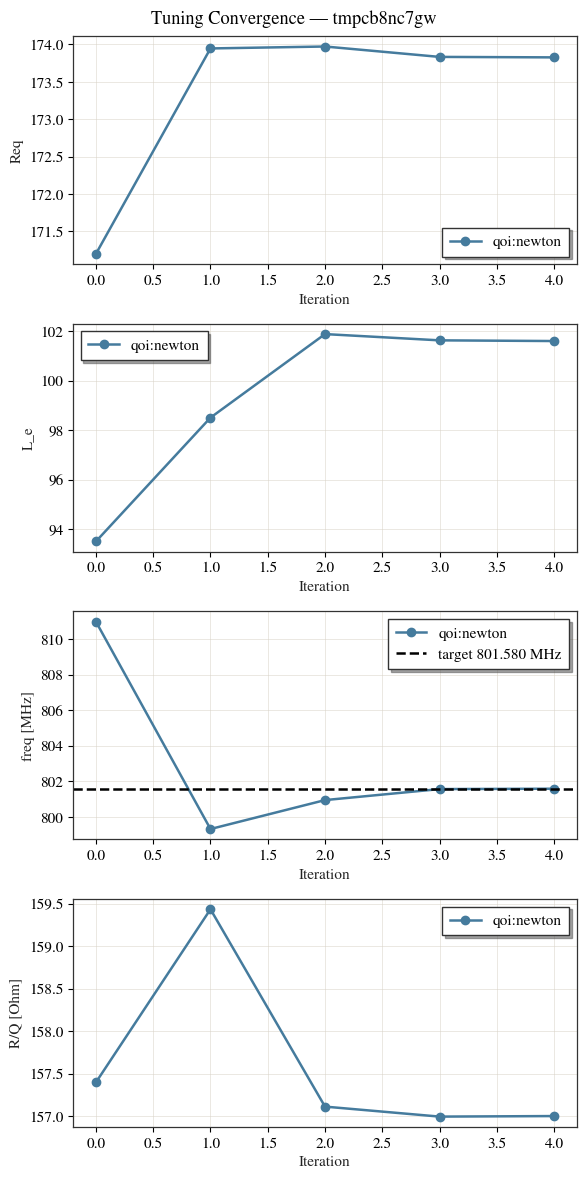

In [3]:
fig, axes = cav.tune.plot_convergence(show=False)
plt.show()

Field flatness comes out at 100 % by symmetry — every 2-cell design is flat — so the two
targets simply pick the single member that also carries the requested `R/Q`. The equality
is satisfied exactly rather than traded off, through the ordinary `cav.tune.run(config)`.

## 2. Fewer variables than targets: the tune refuses

One variable against two targets is over-determined. The tune stops rather than
returning a design that misses:

In [4]:
try:
    cav.tune.run({'freqs': F, 'cell_type': {'end-cell': ['Req']},
                  'qoi_targets': {'R/Q [Ohm]': 157.0}})
except ValueError as e:
    print('correctly refused:', e)

correctly refused: Over-constrained: 2 target(s) but 1 tune variable(s). Give at least as many variables as targets.


## 3. More variables than targets: a family

Three variables against two targets leaves one degree of freedom, so the answer is a
family of designs that all hold the frequency and from which the `R/Q` selects.
`cav.tune.family` holds the members. (This is the same mechanism as the
[two-cell design family](two_cell_design_family.ipynb), with a QoI target added.)

In [5]:
cav.tune.run({'freqs': F,
              'cell_type': {'end-cell': ['Req', 'L', 'A']},   # 3 variables
              'qoi_targets': {'R/Q [Ohm]': 157.0},            # freq + R/Q = 2 targets
              'eigenmode_config': {'mesh_config': MESH}})
family = cav.tune.family
print('family of %d designs at %.2f MHz' % (len(family), F))

family of 4 designs at 801.58 MHz


Every member holds the frequency; the remaining shape freedom trades the figures of merit
against each other. Overlay the geometries, then read `R/Q`, `G`, `Q` and the peak-field
ratios across the family — pick the member whose `R/Q` you asked for, and judge the rest.

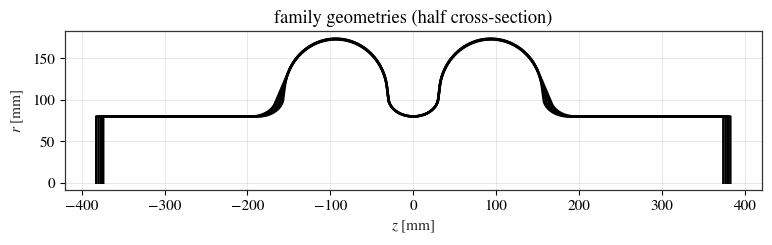

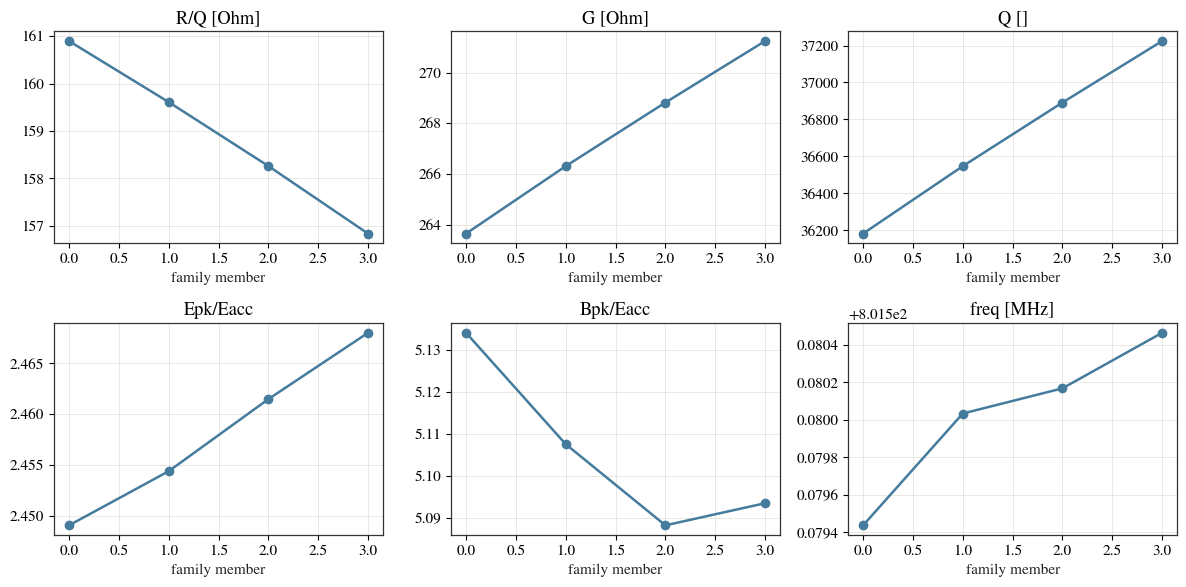

,member,freq [MHz],R/Q [Ohm],G [Ohm],Q [],Epk/Eacc,Bpk/Eacc
0,0,801.579,160.897,263.652,36182.702,2.449,5.134
1,1,801.580,159.609,266.309,36547.334,2.454,5.108
2,2,801.580,158.260,268.817,36891.453,2.461,5.088
3,3,801.580,156.834,271.239,37223.916,2.468,5.093


In [6]:
fig, axg = plt.subplots(figsize=(9, 2.8))
rows = []
for i, m in enumerate(family):
    fresh = EllipticalCavity(2, m.mid_cell, m.end_cell_left, m.end_cell_right, beampipe='both')
    if fresh.profile() is None:                 # skip any borderline geometry
        continue
    fresh.plot('geometry', ax=axg, show=False)
    acc = solve_qois(fresh, 2)
    rows.append({'member': i, 'freq [MHz]': float(acc['freq [MHz]']),
                 'R/Q [Ohm]': float(acc['R/Q [Ohm]']), 'G [Ohm]': float(acc['G [Ohm]']),
                 'Q []': float(acc['Q []']), 'Epk/Eacc': float(acc['Epk/Eacc []']),
                 'Bpk/Eacc': float(acc['Bpk/Eacc [mT/MV/m]'])})
axg.set_title('family geometries (half cross-section)')
plt.show()

df = pd.DataFrame(rows)
fig, ax = plt.subplots(2, 3, figsize=(12, 6))
for a, col in zip(ax.flat, ['R/Q [Ohm]', 'G [Ohm]', 'Q []',
                            'Epk/Eacc', 'Bpk/Eacc', 'freq [MHz]']):
    a.plot(df['member'], df[col], 'o-', color=WARM[0])
    a.set_title(col)
    a.set_xlabel('family member')
plt.tight_layout()
plt.show()
df.round(3)

## 4. More than two cells: one target for the whole cavity

For a cavity with more than two cells you normally know the `R/Q` you want from the
cavity as a whole, not cell by cell. You can ask for exactly that, because `R/Q` is
additive over half-cells (cups).

The bookkeeping is in cups, not cells: a 3-cell cavity is four mid cups and two end cups,
because each end cell is one beam-pipe end cup plus one interior mid cup. Tune the mid cup
(periodic) and the end cup (the symmetric beam-pipe cell it mirrors) to the same
frequency, then check the sum against the assembled 3-cell:

In [7]:
F = 801.58
# MID cup: periodic mid cell (mm BCs) tuned to F via Req; cup R/Q = R/Q_periodic / 2
cavm = EllipticalCavity(1, C3795_72, C3795_72, C3795_72, beampipe='none')
cavm.set_workspace(tempfile.mkdtemp())
cavm.tune.run({'freqs': F, 'cell_type': {'mid-cell': 'Req'},
               'eigenmode_config': {'boundary_conditions': 'mm', 'mesh_config': MESH}})
Req_mid = float(cavm.tuned.parameters['Req_m'])
accm = solve_qois(cavm.tuned, 1, boundary_conditions='mm')
mid_cup = float(accm['R/Q [Ohm]']) / 2
print('mid cup : Req=%.3f  periodic freq=%.3f  R/Q=%.3f -> mid_cup=%.3f'
      % (Req_mid, accm['freq [MHz]'], accm['R/Q [Ohm]'], mid_cup))

# END cup: symmetric beampipe cell (SHARED Req) tuned to F via L; cup R/Q = R/Q_sym / 2
endp = C3795_72[:]; endp[6] = Req_mid
cave = EllipticalCavity(1, endp, endp, endp, beampipe='both')
cave.set_workspace(tempfile.mkdtemp())
cave.tune.run({'freqs': F, 'cell_type': {'end-cell': 'L'}, 'eigenmode_config': {'mesh_config': MESH}})
L_end = float(cave.tuned.parameters['L_el'])
acce = solve_qois(cave.tuned, 1)
end_cup = float(acce['R/Q [Ohm]']) / 2
print('end cup : L=%.3f  beampipe freq=%.3f  R/Q=%.3f -> end_cup=%.3f'
      % (L_end, acce['freq [MHz]'], acce['R/Q [Ohm]'], end_cup))

# ASSEMBLE the 3-cell (4 mid-cups + 2 end-cups), shared Req, and compare
mid7 = C3795_72[:]; mid7[6] = Req_mid
end7 = C3795_72[:]; end7[6] = Req_mid; end7[5] = L_end
cav3 = EllipticalCavity(3, mid7, end7, end7, beampipe='both')
acc3 = solve_qois(cav3, 3)
pred = 4 * mid_cup + 2 * end_cup
print('\n3-cell  : freq=%.3f  ff=%.2f%%  R/Q=%.3f' % (acc3['freq [MHz]'], acc3['ff [%]'], acc3['R/Q [Ohm]']))
print('predict : 4*mid_cup + 2*end_cup = %.3f' % pred)
print('diff    : %+.3f Ohm  (%+.2f %%)'
      % (acc3['R/Q [Ohm]'] - pred, 100 * (acc3['R/Q [Ohm]'] - pred) / pred))

mid cup : Req=171.198  periodic freq=801.582  R/Q=92.825 -> mid_cup=46.413


end cup : L=101.576  beampipe freq=801.505  R/Q=88.554 -> end_cup=44.277



3-cell  : freq=801.583  ff=96.50%  R/Q=274.124
predict : 4*mid_cup + 2*end_cup = 274.204
diff    : -0.080 Ohm  (-0.03 %)


The sum matches the assembled cavity to a few hundredths of a percent. The end cup's `R/Q`
differs from the mid cup's — the beam pipe loads it — but once the end cell is counted as
end cup plus interior mid cup, the split is essentially exact.

That additivity is what lets a cavity with more than two cells be tuned cup by cup from a
total `R/Q`, and here the variable count carries the intent per cell. The mid cell gets one
variable (`Req`) and is tuned to frequency only, its cup `R/Q` falling out of the solve.
The end cell gets two (`L`, `A`) and is tuned to the frequency and to its derived share,
`total − (2N−2)·mid_cup`. `R/Q` is moved with the local `A`, never with the shared `Req`,
which would detune every other cup.

In [8]:
cav5 = EllipticalCavity(5, C3795_72, C3795_72, C3795_72, beampipe='both', name='c5')
cav5.set_workspace(tempfile.mkdtemp())
cav5.tune.run({'freqs': F,
               'qoi_targets': {'R/Q [Ohm]': 450},            # the cavity total
               'cell_type': {'mid-cell': 'Req',              # 1 variable -> frequency only
                             'end-cell': ['L', 'A']},        # 2 variables -> frequency + R/Q
               'eigenmode_config': {'mesh_config': MESH}})
st = cav5.tune.qois['staged']
print('mid_cup = %.2f   ->   derived end_cup = %.2f' % (st['mid_cup'], st['end_cup']))
print('achieved: %s   (target R/Q 450)' % {k: round(v, 2) for k, v in st['QOIS'].items()})

mid_cup = 46.41   ->   derived end_cup = 40.03
achieved: {'freq [MHz]': 801.62, 'R/Q [Ohm]': 449.92, 'ff [%]': 93.58}   (target R/Q 450)


The achieved dictionary carries the field flatness alongside the frequency and `R/Q`, and
it is worth reading. Every cup is tuned to the same frequency, so the field is flat by
construction only to the extent that the cup decomposition is exact — here the 5-cell
lands at `ff` a few percent below 100 while holding the total `R/Q` to within 0.1 Ω. If
you need the flatness tighter than that, make it a target of its own: add `'ff [%]'` to
`qoi_targets` and a third tune variable to pay for it.

The convergence shows the two stages: the mid-cell frequency tune, then the end-cell
frequency-and-`R/Q` tune.

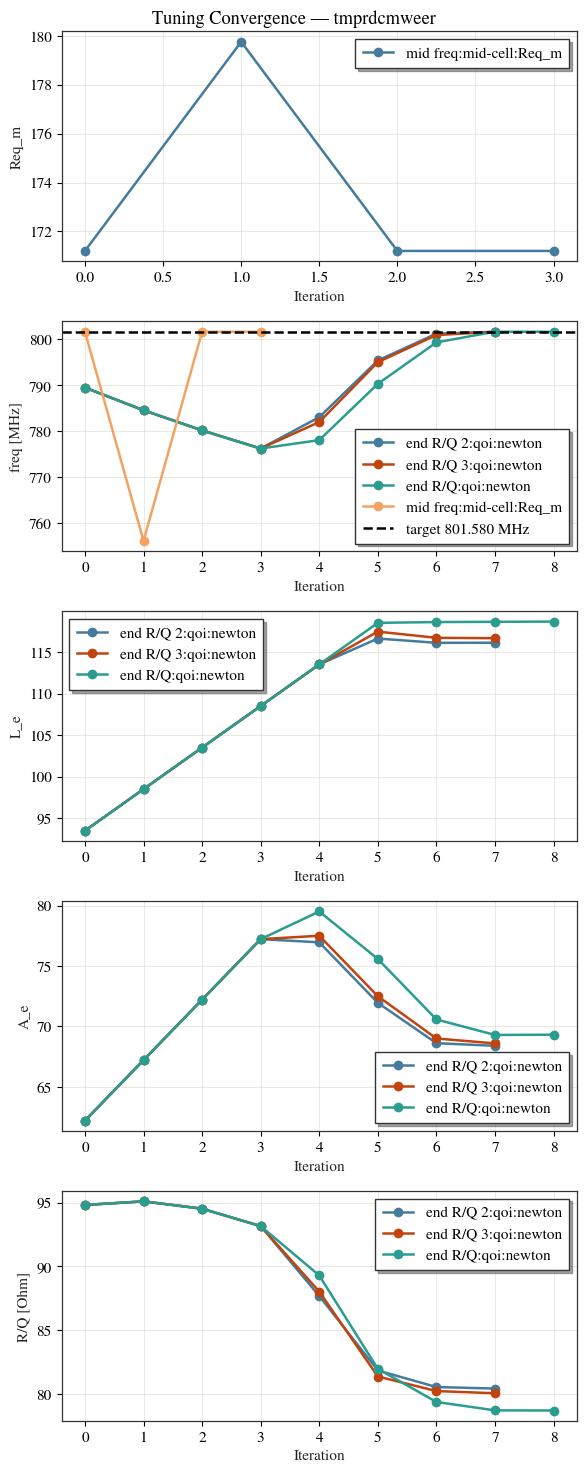

In [9]:
fig, axes = cav5.tune.plot_convergence(show=False)
plt.show()

If the split cannot be met the tune stops with a reason instead of returning a geometry
that misses. A 5-cell cavity cannot reach a total `R/Q` of 300 — its eight mid cups
already contribute about 370:

In [10]:
import json
import os

bad = EllipticalCavity(5, C3795_72, C3795_72, C3795_72, beampipe='both')
bad.set_workspace(tempfile.mkdtemp())
bad.tune.run({'freqs': F, 'qoi_targets': {'R/Q [Ohm]': 300},
              'cell_type': {'mid-cell': 'Req', 'end-cell': ['L', 'A']},
              'eigenmode_config': {'mesh_config': MESH}})
status = json.load(open(os.path.join(bad.self_dir, 'tuned', 'tune_info', 'tune_status.json')))
print('tuned:', bad.tuned, ' | status:', status['status'], '->', status['reason'])

ERROR:: Staged tune tmpdy6vuc3x: NO SOLUTION -- the 8 mid cups already contribute R/Q=371.30, at/above the total target 300.00. Raise the total or lower the mid contribution.
tuned: None  | status: failed -> mid contribution exceeds total


## Where to go next

- The [tuning guide](../../tuning) documents `qoi_targets` and `qoi_split`, which lets you
  set the per-section `R/Q` share yourself instead of deriving it.
- [Two-cell design family](two_cell_design_family.ipynb) — the same residual freedom, with
  frequency as the only target.
- [Optimisation](../optimisation/index) — with the equality pinned in the tune, the Pareto
  search ranks only designs that already satisfy it.